# Einführung

# Aspektanalyse von Kundenbewertungen: Eigenes NER-Modell und Klassifikator

Dieses Notebook untersucht echte, englischsprachige Fahrzeugbewertungen von **CarWale**
(carwale.com) für ausgewählte deutsche und chinesische Automarken. Es bildet die dritte,
strukturell eigenständige Analyseachse dieses Projekts, neben den realen Marktergebnissen/
dem Sucheinteresse (`consumer_interest_analysis.ipynb`) und der Medienberichterstattung
(`news_media_nlp_analysis.ipynb`): Statt Marktanteilen oder Medienaufmerksamkeit misst dieses
Kapitel, **worüber** echte Kundinnen und Kunden in ihren Bewertungen tatsächlich sprechen --
Motor, Komfort, Service, Sicherheit, Preis, ... -- mittels eines eigens trainierten,
regelbasierten NER-Modells und eines darauf aufbauenden Klassifikators.

**Alle Logik liegt in `src/car_interest_nlp/reviews/` -- dieses Notebook ruft ausschließlich
bereits implementierte Funktionen auf**, genau wie `consumer_interest_analysis.ipynb` und
`news_media_nlp_analysis.ipynb`. Dieses Kapitel portiert und bereinigt die ursprüngliche
Analyse eines Kollegen (vormals vier separate Notebooks im Ordner `Car_Brands/`) in dieselbe
Projektstruktur: Web-Scraping, Textbereinigung, NER-Training und Klassifikation sind jeweils
eigene Module, nicht Notebook-Code.

## Einordnung und reale Einschränkungen

- **Web-Scraping (CarWale) statt einer offiziellen API.** CarWale bietet keine öffentliche
  API für Bewertungen an; `src/car_interest_nlp/reviews/scraping.py` liest die real
  veröffentlichten Bewertungsseiten direkt aus dem HTML. Jede Marke/Modell-Kombination wird
  einzeln zwischengespeichert (analog zu den GDELT-Chunks im anderen Notebook), sodass ein
  erneuter Lauf bereits gecachte Modelle nie erneut abruft.
- **Live-/Cache-Modus, wie im GDELT-Kapitel.** `REVIEWS_FETCH_MODE` steuert das Scraping:
  `"live"` ruft tatsächlich fehlende Bewertungen ab, `"cached"` sendet keine einzige Anfrage
  und meldet nur den aktuellen, bereits zwischengespeicherten Stand. `REVIEW_NER_MODE` steuert
  entsprechend das (deutlich langsamere) NER-Training: Ein bereits trainiertes Modell unter
  `data/interim/reviews/ner_model/` wird bei `"cached"` wiederverwendet statt erneut
  trainiert.
- **Die manuell annotierten Trainingsdaten sind echte, von Hand erstellte Daten, keine
  automatisiert generierten.** `data/raw/reviews/cars_reviews_ner_inline.txt` (174
  Bewertungen mit inline markierten Aspekt-Entitäten, z. B. `[driving experience]_PERFORMANCE`)
  und `data/raw/reviews/cars_reviews_labeled.json` (dieselben Bewertungen, je mit einer
  übergeordneten Aspektklasse versehen) stammen aus der ursprünglichen manuellen
  Annotationsarbeit und werden unverändert weiterverwendet -- sie werden nicht neu erzeugt.
- **Eigenes NER-Modell, von Grund auf trainiert (kein Fine-Tuning).** Anders als das
  GDELT-Kapitel (das ein reales vortrainiertes spaCy-Modell feintunt) wird hier ein leeres
  englisches spaCy-Modell (`spacy.blank("en")`) trainiert: Die Aspekt-Labels (ENGINE, COMFORT,
  SERVICE, ...) sind bewertungsspezifischer Fachjargon ohne Entsprechung in einem
  allgemeinen vortrainierten Modell -- ein Training von Grund auf entspricht daher dem
  Original-Ansatz und ist hier die richtige Wahl.
- **Die verwendeten Entitäts-Labels werden aus den echten Trainingsdaten ermittelt, nicht
  hart codiert.** `reviews.text_prep.discover_entity_labels()` sammelt alle tatsächlich in
  `cars_reviews_ner_inline.txt` vorkommenden Labels; dieselbe Liste wird sowohl für das
  NER-Training als auch für die spätere Merkmalsextraktion verwendet. Das behebt eine reale
  Inkonsistenz im ursprünglichen Projekt, in dem die für die Merkmalsextraktion hart codierte
  Label-Liste (`BUILD_QUALITY`, `SPARE_PART`, `FUEL_CONSUMPTION`, `VALUE_FOR_MONEY`) von den
  tatsächlich im Trainingstext annotierten Labels (`BUILD`, `SPARE`, `FUEL`, `VALUE`) abwich
  -- vier Merkmalsspalten wären dadurch immer Null gewesen.
- **Markengruppen (Deutsch/Chinesisch) werden über `configs/brands.yaml` aufgelöst**, nicht
  über eine separat hart codierte Zuordnung -- `reviews.inference.add_brand_group_columns()`
  nutzt dieselbe `preprocessing.brand_matching`-Logik wie die KBA-/Schweiz-Kapitel im anderen
  Notebook.
- **Kreuzvalidierung verwendet explizit `scoring="f1_macro"`.** Das Original-Notebook rief
  `cross_val_score(...)` ohne `scoring=` auf, was für einen Klassifikator standardmäßig auf
  Accuracy statt Macro-F1 zurückfällt, obwohl die Dokumentation "Macro F1" auswies -- hier
  wird die Metrik explizit gesetzt, damit tatsächlich das berechnet wird, was gemeint ist.


In [1]:
import numpy as np
from IPython.display import Image, display

from car_interest_nlp.config import load_project_config, resolve_project_path
from car_interest_nlp.paths import FIGURES_DIR
from car_interest_nlp.progress import TimeBudget
from car_interest_nlp.reviews.classification import (
    discover_aspect_classes,
    build_labels_array,
    ensure_aspect_classifier,
)
from car_interest_nlp.reviews.features import build_entity_count_matrix
from car_interest_nlp.reviews.inference import add_brand_group_columns, predict_aspects
from car_interest_nlp.reviews.ner_training import ensure_review_ner_model
from car_interest_nlp.reviews.scraping import ensure_reviews_dataset, load_cached_reviews
from car_interest_nlp.reviews.text_prep import (
    build_ner_training_records,
    discover_entity_labels,
    load_inline_annotated_articles,
    load_labeled_reviews,
)
from car_interest_nlp.visualization.reviews import (
    plot_average_rating_by_aspect_and_group,
    plot_confusion_matrix,
    plot_predicted_aspect_distribution,
)

config = load_project_config()
reviews_config = config["sources"]["reviews"]

# "live" fetches whatever real CarWale reviews are still missing; "cached" never sends a
# single request and only works with whatever is already cached under data/raw/reviews/ --
# switch to "cached" once scraping is done, so re-running this notebook (e.g. to redo
# training/plots) never touches the real site again. Same convention as GDELT_FETCH_MODE in
# news_media_nlp_analysis.ipynb.
REVIEWS_FETCH_MODE = "live"

# "cached" reuses an already-trained review NER model under data/interim/reviews/ner_model/
# if present; "live" always retrains. NER training is the slowest local step in this
# notebook (DEFAULT_N_EPOCHS epochs over the full hand-annotated corpus).
REVIEW_NER_MODE = "cached"

# Same live/cached convention for the aspect classifier -- cross-validation/training is
# cheap here (a few hundred count-feature rows), but reusing a cached model still avoids
# unnecessary recomputation on every re-run.
REVIEW_CLASSIFIER_MODE = "cached"

# Time budgets for the two genuinely long-running phases, set here as plain variables (not
# hardcoded inside the .py files) so this run's actual budget is visible at a glance.
REVIEW_SCRAPE_TIME_LIMIT_MINUTES = 60.0
REVIEW_NER_TRAINING_TIME_LIMIT_MINUTES = 15.0

NER_MODEL_DIR = resolve_project_path("data/interim/reviews/ner_model")
CLASSIFIER_DIR = resolve_project_path("data/interim/reviews/classifier")

D:\Master\Projects\NLP_German_vs_Chinese_Cars\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Bewertungen sammeln (Web-Scraping, real, cachebar)

`ensure_reviews_dataset()` lädt reale CarWale-Bewertungen für die in `configs/sources.yaml`
(`reviews.tracked_brands`, Standard: BYD, Volkswagen) hinterlegten Marken herunter -- je
Marke werden die ersten `reviews.models_per_brand` Fahrzeugmodelle ermittelt und deren
Bewertungsseiten seitenweise durchsucht, bis eine Seite weniger als
`reviews.min_cards_per_page` Bewertungskarten enthält. Jede Marke/Modell-Kombination wird
einzeln unter `data/raw/reviews/` zwischengespeichert; bereits vorhandene Kombinationen
werden nie erneut abgerufen. `mode=REVIEWS_FETCH_MODE` steuert Live-/Cache-Modus (siehe
Einführung oben).


In [2]:
scrape_summary = ensure_reviews_dataset(
    brand_slugs=reviews_config["tracked_brands"],
    models_per_brand=reviews_config["models_per_brand"],
    max_pages=reviews_config["max_pages_per_model"],
    min_cards_per_page=reviews_config["min_cards_per_page"],
    user_agent=reviews_config["user_agent"],
    rate_limit_seconds=reviews_config["rate_limit_seconds"],
    mode=REVIEWS_FETCH_MODE,
    time_budget=TimeBudget(minutes=REVIEW_SCRAPE_TIME_LIMIT_MINUTES),
)
print(scrape_summary)

scraped_reviews = load_cached_reviews()
print(f"Cached reviews available: {len(scraped_reviews)}")
scraped_reviews.head()

2026-07-17 06:05:56,584 | INFO | Discovering models for https://www.carwale.com/byd-cars


2026-07-17 06:05:57,745 | INFO | Discovering models for https://www.carwale.com/volkswagen-cars


CarWale reviews:   0%|          | 0/8 [00:00<?, ?item/s]

CarWale reviews: 100%|██████████| 8/8 [00:00<00:00, 1083.62item/s]


2026-07-17 06:05:58,543 | INFO | CarWale reviews fetch summary: 8 cached, 0 newly fetched, 0 failed, 8 total


{'cached': 8, 'fetched': 0, 'failed': 0, 'total': 8}
Cached reviews available: 174


,Title,Comment,Rating,brand_slug
0,"No sound, smooth riding, comfortable. Best 5 ...","The driving experience is awesome. No sound, ...",4,byd-cars
1,Dont Buy - After sales is awwful... you will b...,Me and my colleague bought BYD Atto 3 months a...,1,byd-cars
2,The BYD Atto 3 claims to offer a distance of 4...,The BYD Atto 3 claims to offer a distance of 4...,1,byd-cars
3,DO NOT BUY BYD CAR PLEASE READ THE COMMENTS AN...,"Worst is better word for me to use here,car pe...",1,byd-cars
4,Car is good but after service is very bad,If there’s an opportunity to provide feedback ...,1,byd-cars


# Manuell annotierte Trainingsdaten laden

Zwei echte, von Hand erstellte Dateien bilden die Grundlage für das NER-Training und die
Aspektklassifikation und werden hier unverändert geladen (siehe Einführung oben):

- `data/raw/reviews/cars_reviews_ner_inline.txt`: 174 Bewertungen mit inline markierten
  Aspekt-Entitäten im Format `[Textausschnitt]_LABEL` (z. B. `[driving experience]_PERFORMANCE`).
  `text_prep.load_inline_annotated_articles()` teilt die Datei anhand langer Trennlinien in
  einzelne Bewertungen, `text_prep.build_ner_training_records()` bereinigt jede Bewertung
  (URLs/E-Mails/Telefonnummern/überflüssige Leerzeichen entfernen) und wandelt die
  Klammer-Markierungen in spaCy-Zeichenoffsets um.
- `text_prep.discover_entity_labels()` ermittelt die tatsächlich vorkommenden Aspekt-Labels
  direkt aus diesen Trainingsdaten (siehe Einführung oben zur damit behobenen
  Label-Inkonsistenz des Originalprojekts).


In [3]:
ner_inline_path = resolve_project_path("data/raw/reviews/cars_reviews_ner_inline.txt")
labeled_reviews_path = resolve_project_path("data/raw/reviews/cars_reviews_labeled.json")

annotated_articles = load_inline_annotated_articles(ner_inline_path)
ner_training_records = build_ner_training_records(annotated_articles)
entity_labels = discover_entity_labels(ner_training_records)

labeled_reviews = load_labeled_reviews(labeled_reviews_path)
aspect_classes = discover_aspect_classes(labeled_reviews)

print(f"NER training records: {len(ner_training_records)}")
print(f"Entity labels ({len(entity_labels)}): {entity_labels}")
print(f"Labeled reviews: {len(labeled_reviews)}")
print(f"Aspect classes ({len(aspect_classes)}): {aspect_classes}")

NER training records: 174
Entity labels (23): ['ADAS', 'AIRBAG', 'BATTERY', 'BUILD', 'CHARGING', 'COMFORT', 'DESIGN', 'ENGINE', 'FEATURE', 'FUEL', 'HANDLING', 'INTERIOR', 'PERFORMANCE', 'PRICE', 'PROBLEM', 'RANGE', 'REPAIR', 'SAFETY', 'SEAT', 'SERVICE', 'SPACE', 'SPARE', 'VALUE']
Labeled reviews: 174
Aspect classes (7): ['comfort', 'service', 'battery-fuel consumption', 'price', 'performance-quality', 'safety', 'design-features']


# Eigenes Aspekt-NER-Modell trainieren

`ensure_review_ner_model()` trainiert ein leeres englisches spaCy-Modell auf den echten,
hand-annotierten Trainingsdaten von oben -- `mode=REVIEW_NER_MODE` steuert, ob ein bereits
trainiertes Modell unter `NER_MODEL_DIR` wiederverwendet wird (`"cached"`, Standard) oder ob
stets neu trainiert wird (`"live"`). Der Fortschritt wird über eine einzige Live-Fortschrittsleiste
(nicht eine Log-Zeile je Epoche) angezeigt; `REVIEW_NER_TRAINING_TIME_LIMIT_MINUTES` bricht
das Training bei Bedarf zwischen zwei Epochen sauber ab. Anschließend wird das trainierte
Modell an einer Beispielbewertung demonstriert.


In [4]:
import spacy

review_ner_model = ensure_review_ner_model(
    ner_training_records,
    labels=entity_labels,
    output_dir=NER_MODEL_DIR,
    mode=REVIEW_NER_MODE,
    time_budget=TimeBudget(minutes=REVIEW_NER_TRAINING_TIME_LIMIT_MINUTES),
)

example_doc = review_ner_model(ner_training_records[0]["text"])
spacy.displacy.render(example_doc, style="ent")

D:\Master\Projects\NLP_German_vs_Chinese_Cars\.venv\Lib\site-packages\spacy\training\iob_utils.py:149: UserWarning: [W030] Some entities could not be aligned in the text "TITLE:
No sound, smooth riding, comfortable. Best ..." with entities "[(88, 106, 'PERFORMANCE'), (144, 155, 'COMFORT'), ...". Use `spacy.training.offsets_to_biluo_tags(nlp.make_doc(text), entities)` to check the alignment. Misaligned entities ('-') will be ignored during training.
  warnings.warn(
D:\Master\Projects\NLP_German_vs_Chinese_Cars\.venv\Lib\site-packages\spacy\training\iob_utils.py:149: UserWarning: [W030] Some entities could not be aligned in the text "TITLE:
Dont Buy - After sales is awwful... you wil..." with entities "[(273, 279, 'REPAIR'), (333, 339, 'REPAIR'), (373,...". Use `spacy.training.offsets_to_biluo_tags(nlp.make_doc(text), entities)` to check the alignment. Misaligned entities ('-') will be ignored during training.
  warnings.warn(
D:\Master\Projects\NLP_German_vs_Chinese_Cars\.venv\Lib\site

Review NER training epochs:   0%|          | 0/50 [00:00<?, ?epoch/s]

Review NER training epochs:   0%|          | 0/50 [00:02<?, ?epoch/s, loss=8109.3623]

Review NER training epochs:   2%|▏         | 1/50 [00:02<02:00,  2.47s/epoch, loss=8109.3623]

Review NER training epochs:   2%|▏         | 1/50 [00:04<02:00,  2.47s/epoch, loss=2356.8730]

...

Review NER training epochs:  98%|█████████▊| 49/50 [02:19<00:02,  2.77s/epoch, loss=9.4613]

Review NER training epochs:  98%|█████████▊| 49/50 [02:21<00:02,  2.77s/epoch, loss=11.2806]

Review NER training epochs: 100%|██████████| 50/50 [02:21<00:00,  2.70s/epoch, loss=11.2806]

Review NER training epochs: 100%|██████████| 50/50 [02:21<00:00,  2.83s/epoch, loss=11.2806]


2026-07-17 06:08:20,988 | INFO | Saved trained review NER pipeline to D:\Master\Projects\NLP_German_vs_Chinese_Cars\data\interim\reviews\ner_model


# Merkmalsextraktion (Entity-Counts)

`features.build_entity_count_matrix()` wendet das trainierte NER-Modell auf jede der 174
hand-annotierten Bewertungen an (Titel + Kommentar, wie beim Training) und zählt je
Bewertung, wie oft jedes Aspekt-Label erkannt wurde -- eine (Bewertungen x Labels)-Matrix.
Diese Zählungen bilden die Merkmale für die anschließende Aspektklassifikation; die
Zielgröße `y` ist die jeweils manuell vergebene Aspektklasse aus
`cars_reviews_labeled.json`.


In [5]:
X = build_entity_count_matrix(review_ner_model, labeled_reviews, entity_labels)
y = build_labels_array(labeled_reviews, aspect_classes)

print(f"Feature matrix shape: {X.shape}")
for aspect_class, count in zip(*np.unique(y, return_counts=True), strict=False):
    print(f"  {aspect_classes[int(aspect_class)]}: {count}")

Entity extraction:   0%|          | 0/174 [00:00<?, ?item/s]

Entity extraction:   5%|▌         | 9/174 [00:00<00:01, 88.85item/s]

Entity extraction:  12%|█▏        | 21/174 [00:00<00:01, 106.12item/s]

Entity extraction:  21%|██▏       | 37/174 [00:00<00:01, 129.62item/s]

Entity extraction:  30%|██▉       | 52/174 [00:00<00:00, 137.11item/s]

...

Entity extraction:  76%|███████▌  | 132/174 [00:00<00:00, 149.63item/s]

Entity extraction:  85%|████████▌ | 148/174 [00:01<00:00, 147.90item/s]

Entity extraction:  94%|█████████▎| 163/174 [00:01<00:00, 140.16item/s]

Entity extraction: 100%|██████████| 174/174 [00:01<00:00, 138.65item/s]

Feature matrix shape: (174, 23)
  comfort: 25
  service: 52
  battery-fuel consumption: 31
  price: 29
  performance-quality: 8
  safety: 16
  design-features: 13


# Aspektklassifikation trainieren

`ensure_aspect_classifier()` vergleicht drei Klassifikatoren (SVC, RandomForest,
LogisticRegression) per stratifizierter 4-facher Kreuzvalidierung (`scoring="f1_macro"`,
siehe Einführung oben), wählt das Modell mit dem höchsten mittleren Macro-F1-Wert aus,
trainiert es final auf allen Daten und speichert es unter `CLASSIFIER_DIR` (`mode=
REVIEW_CLASSIFIER_MODE`, wie beim NER-Modell). Die Konfusionsmatrix unten basiert auf
Out-of-Fold-Vorhersagen (`cross_val_predict`), nie auf Vorhersagen für bereits gesehene
Trainingsdaten.


2026-07-17 06:08:22,335 | INFO | SVC: f1_macro scores=[0.49090584 0.46850893 0.51747426 0.50199285] mean=0.4947


2026-07-17 06:08:26,050 | INFO | RandomForest: f1_macro scores=[0.60322129 0.55818943 0.55625327 0.53505495] mean=0.5632


2026-07-17 06:08:26,142 | INFO | LogisticRegression: f1_macro scores=[0.58187685 0.51978022 0.56936714 0.55822868] mean=0.5573


2026-07-17 06:08:31,155 | INFO | Best review aspect classifier: RandomForest (mean f1_macro=0.5632)


2026-07-17 06:08:31,256 | INFO | Saved review aspect classifier artifacts to D:\Master\Projects\NLP_German_vs_Chinese_Cars\data\interim\reviews\classifier


SVC: mean f1_macro=0.495 (folds=[0.49090584 0.46850893 0.51747426 0.50199285])
RandomForest: mean f1_macro=0.563 (folds=[0.60322129 0.55818943 0.55625327 0.53505495])
LogisticRegression: mean f1_macro=0.557 (folds=[0.58187685 0.51978022 0.56936714 0.55822868])
Best model: RandomForest


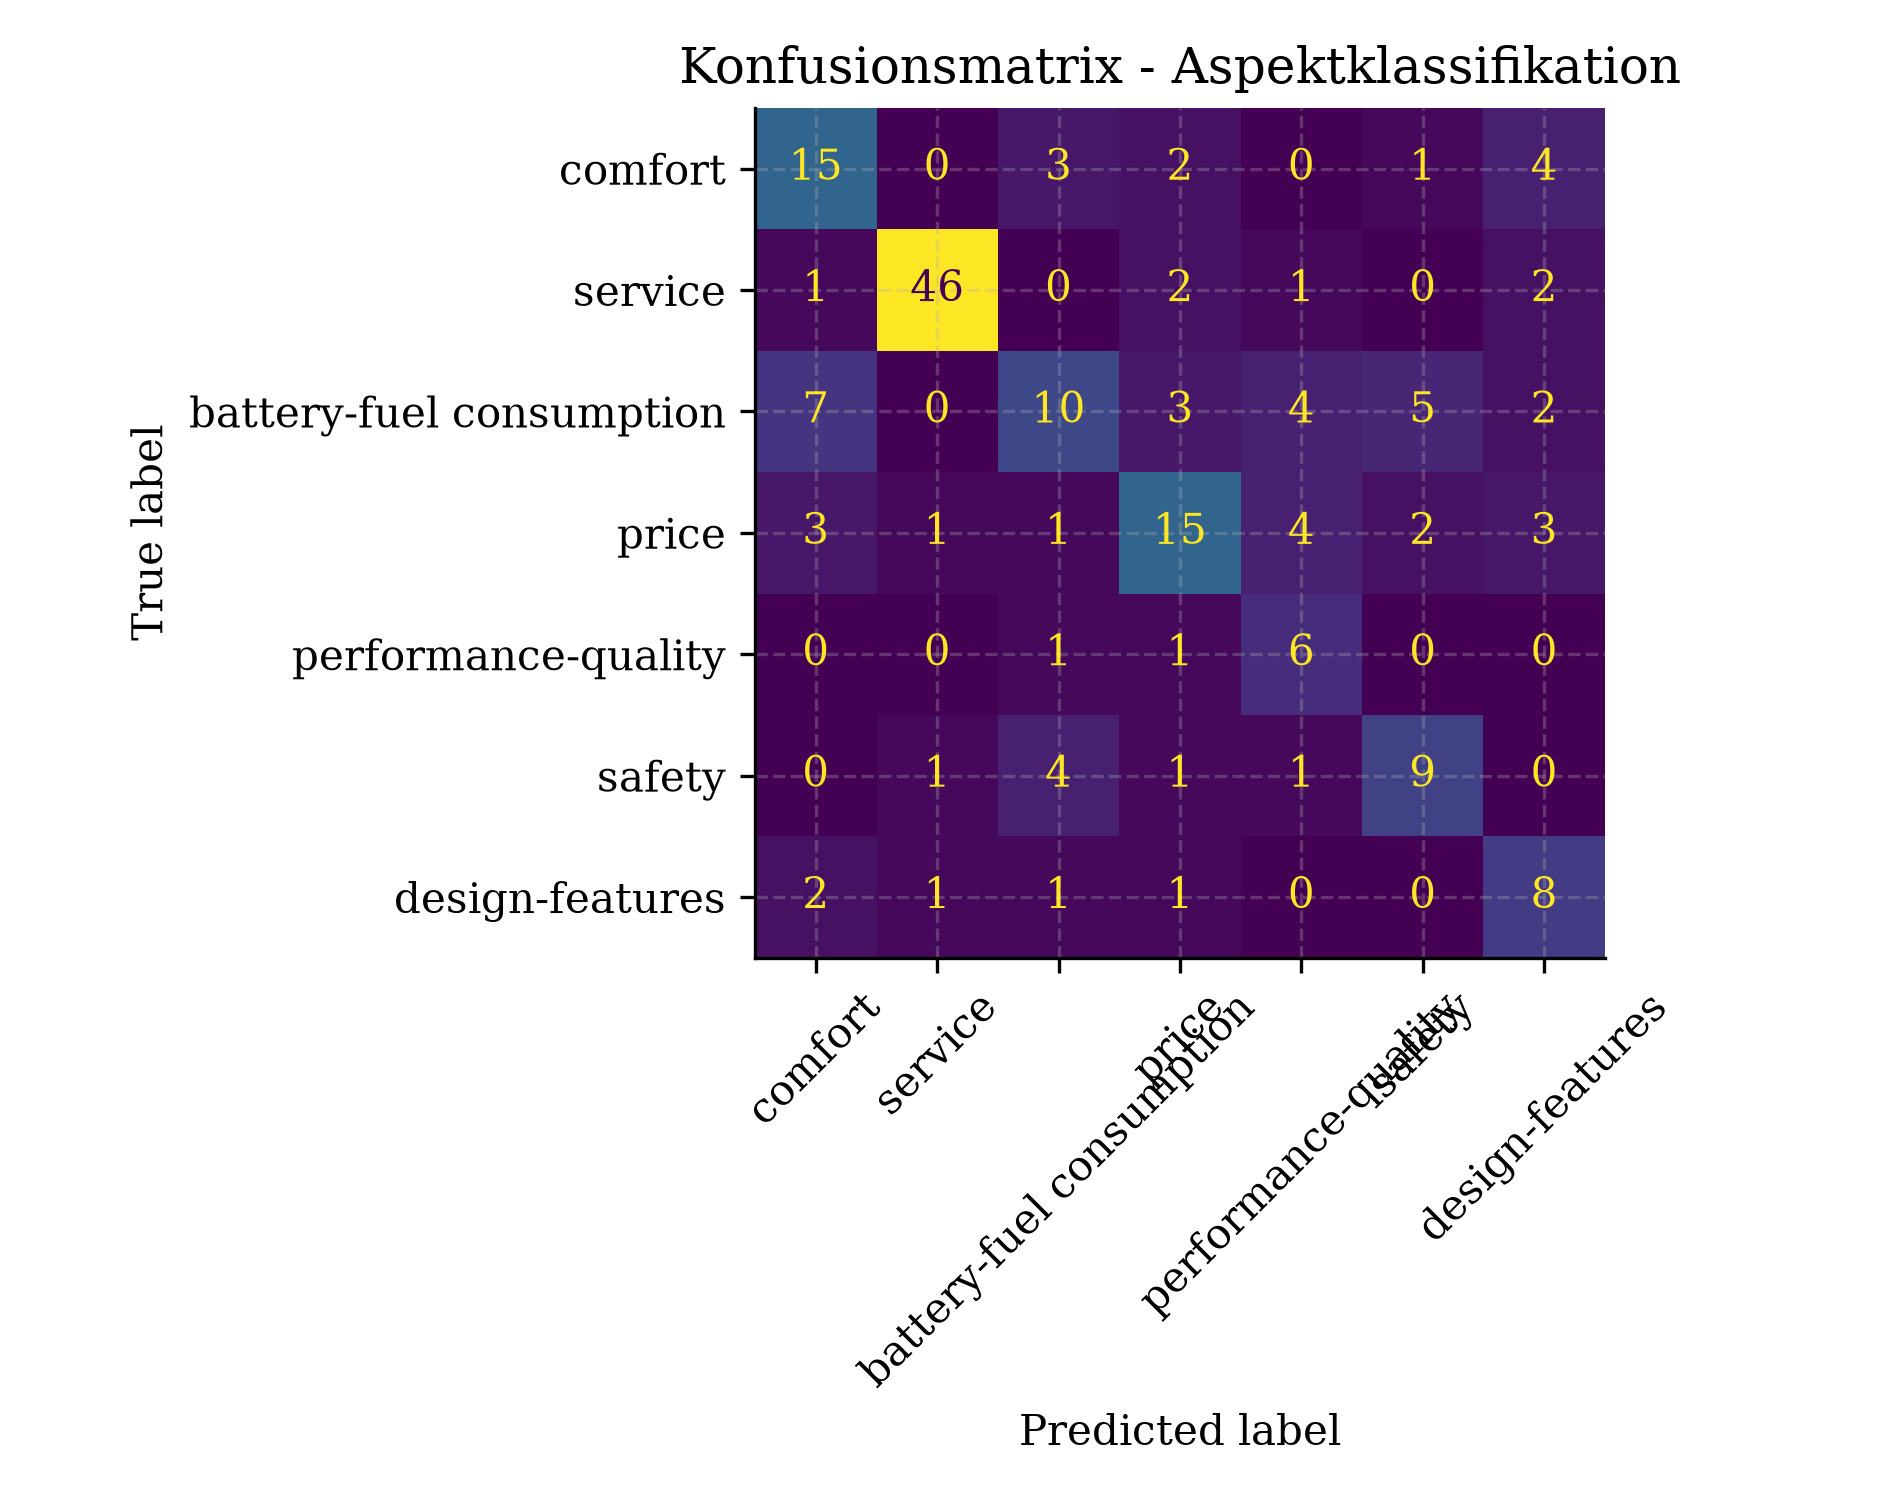

In [6]:
classifier_result = ensure_aspect_classifier(
    X,
    y,
    aspect_classes=aspect_classes,
    entity_labels=entity_labels,
    output_dir=CLASSIFIER_DIR,
    mode=REVIEW_CLASSIFIER_MODE,
)

if not classifier_result["from_cache"]:
    for model_name, scores in classifier_result["cv_results"].items():
        print(f"{model_name}: mean f1_macro={scores['mean_score']:.3f} (folds={scores['scores']})")
    print(f"Best model: {classifier_result['best_model_name']}")

    confusion_matrix_path = plot_confusion_matrix(
        classifier_result["confusion_matrix"],
        aspect_classes,
        FIGURES_DIR / "reviews" / "aspect_confusion_matrix.png",
    )
    display(Image(filename=str(confusion_matrix_path)))
else:
    print(f"Reusing cached classifier at {CLASSIFIER_DIR} -- no fresh cross-validation to display.")

review_classifier = classifier_result["best_model"]

# Anwendung auf neue Bewertungen

Der trainierte NER/Klassifikations-Ablauf wird nun auf einen breiteren, real gescrapten
Bewertungsbestand angewendet: `configs/sources.yaml`'s `reviews.extended_brands` erweitert
die beiden Trainingsmarken um MG (chinesisch) sowie BMW und Mercedes-Benz (deutsch), mit
`reviews.models_per_brand_extended` Modellen je Marke. `ensure_reviews_dataset()` wird dafür
erneut mit derselben `data/raw/reviews/`-Zwischenspeicherung aufgerufen -- bereits gecachte
Marke/Modell-Kombinationen aus dem Trainingsschritt oben werden dabei nie erneut abgerufen,
nur die zusätzlichen Marken/Modelle sind wirklich neu. `inference.predict_aspects()` wendet
NER-Modell und Klassifikator auf jede real gescrapte Bewertung an;
`inference.add_brand_group_columns()` löst die CarWale-Markenslugs gegen dieselbe
`configs/brands.yaml` wie die KBA-/Schweiz-Kapitel im anderen Notebook auf (siehe Einführung
oben).


In [7]:
extended_scrape_summary = ensure_reviews_dataset(
    brand_slugs=reviews_config["extended_brands"],
    models_per_brand=reviews_config["models_per_brand_extended"],
    max_pages=reviews_config["max_pages_per_model"],
    min_cards_per_page=reviews_config["min_cards_per_page"],
    user_agent=reviews_config["user_agent"],
    rate_limit_seconds=reviews_config["rate_limit_seconds"],
    mode=REVIEWS_FETCH_MODE,
    time_budget=TimeBudget(minutes=REVIEW_SCRAPE_TIME_LIMIT_MINUTES),
)
print(extended_scrape_summary)

new_reviews = load_cached_reviews()
new_reviews = new_reviews[new_reviews["brand_slug"].isin(reviews_config["extended_brands"])]
new_reviews = add_brand_group_columns(new_reviews)
print(f"Reviews available for inference: {len(new_reviews)}")

predicted_reviews = predict_aspects(
    review_ner_model,
    review_classifier,
    entity_labels,
    aspect_classes,
    new_reviews,
)
predicted_reviews.head()

2026-07-17 06:08:31,597 | INFO | Discovering models for https://www.carwale.com/byd-cars


2026-07-17 06:08:32,338 | INFO | Discovering models for https://www.carwale.com/mg-cars


2026-07-17 06:08:33,187 | INFO | Discovering models for https://www.carwale.com/volkswagen-cars


2026-07-17 06:08:33,824 | INFO | Discovering models for https://www.carwale.com/bmw-cars


2026-07-17 06:08:34,450 | INFO | Discovering models for https://www.carwale.com/mercedes-benz-cars


...

Entity extraction:  93%|█████████▎| 708/759 [00:04<00:00, 164.84item/s]

Entity extraction:  96%|█████████▌| 725/759 [00:04<00:00, 164.60item/s]

Entity extraction:  98%|█████████▊| 743/759 [00:04<00:00, 166.89item/s]

Entity extraction: 100%|██████████| 759/759 [00:04<00:00, 152.93item/s]

,Title,Comment,Rating,brand_slug,brand,canonical_brand,origin_group,predicted_aspect
0,my,nice car I drive it from a big time this is be...,4,bmw-cars,BMW,BMW,german,design-features
1,Impressed with car looks,"I did not purchase this car, but I drive my fr...",5,bmw-cars,BMW,BMW,german,service
2,Superb Car,Low-budget luxury car with high-quality perfor...,5,bmw-cars,BMW,BMW,german,price
3,Blue berry,"My Dream car I wanna buy, definitely one day a...",5,bmw-cars,BMW,BMW,german,performance-quality
4,Future plan,Elegance in motion.\nLuxury meets performance....,5,bmw-cars,BMW,BMW,german,performance-quality


## Abbildungen

Drei Abbildungen fassen die vorhergesagten Aspekte zusammen: ein Kreisdiagramm und ein
Balkendiagramm der Aspektverteilung über alle neu analysierten Bewertungen, sowie ein
gruppiertes Balkendiagramm der durchschnittlichen Sternebewertung je Aspekt, getrennt nach
Markengruppe (Deutsch vs. Chinesisch, `configs/brands.yaml`).


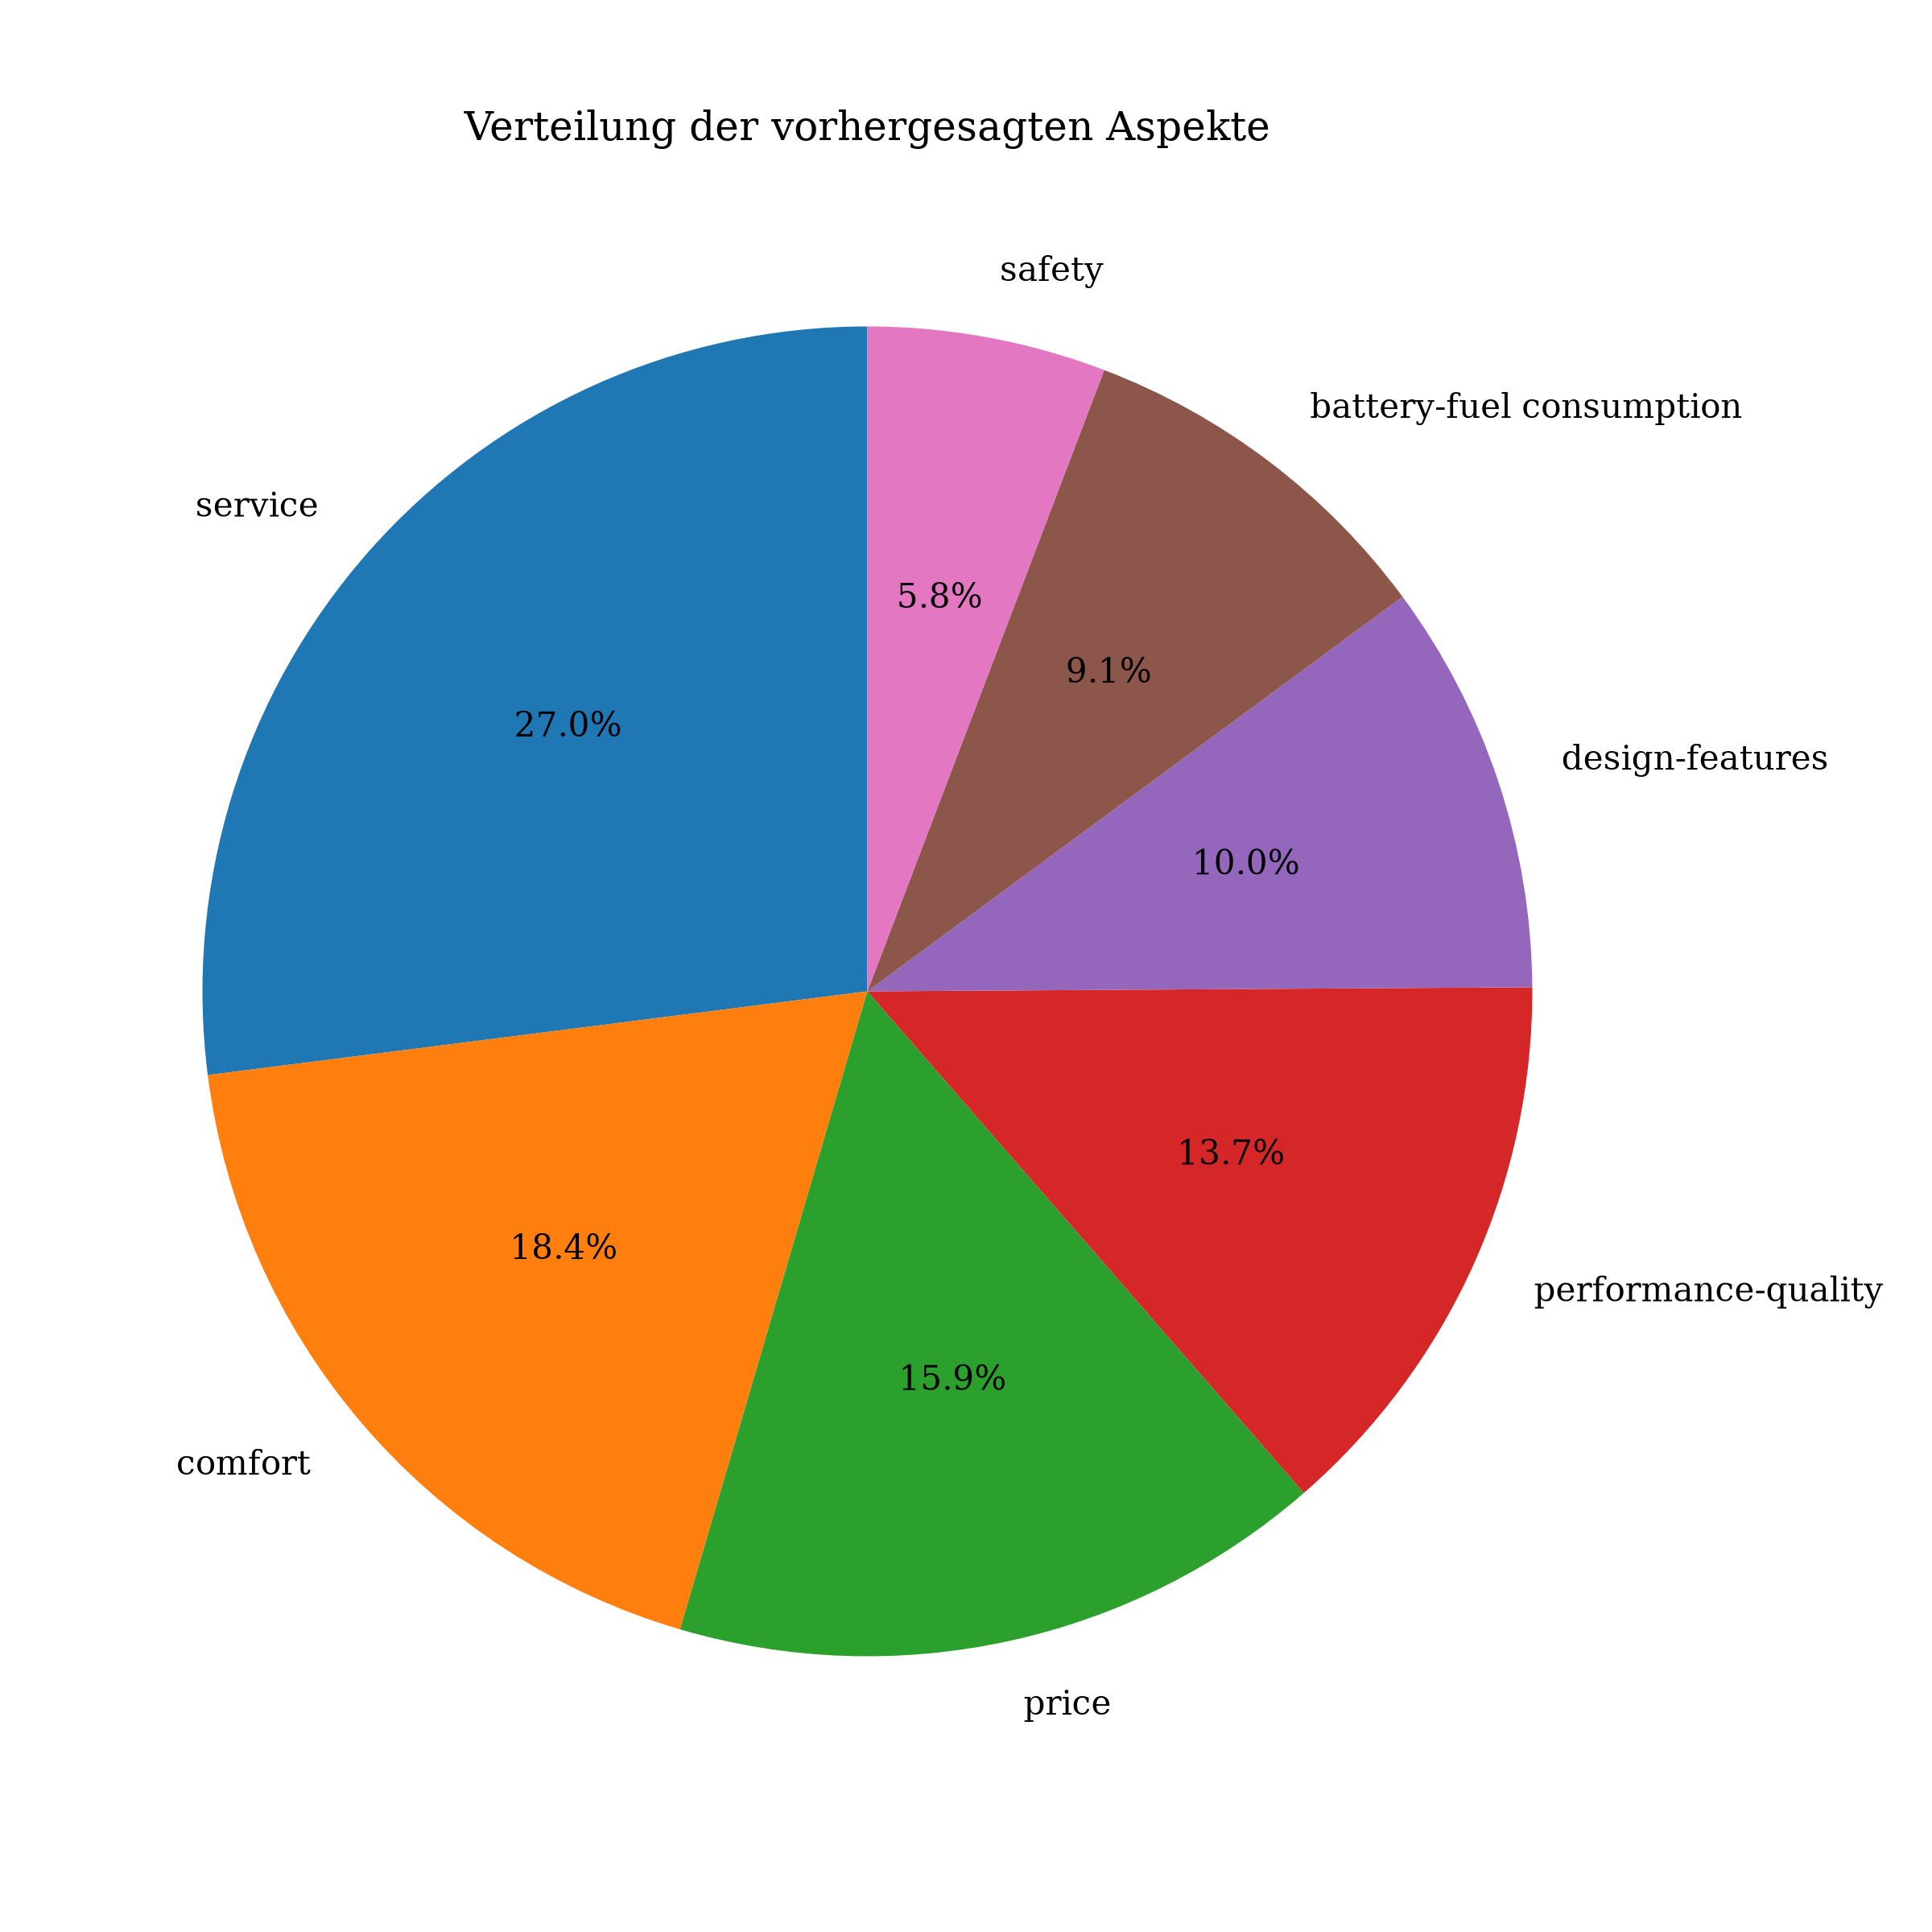

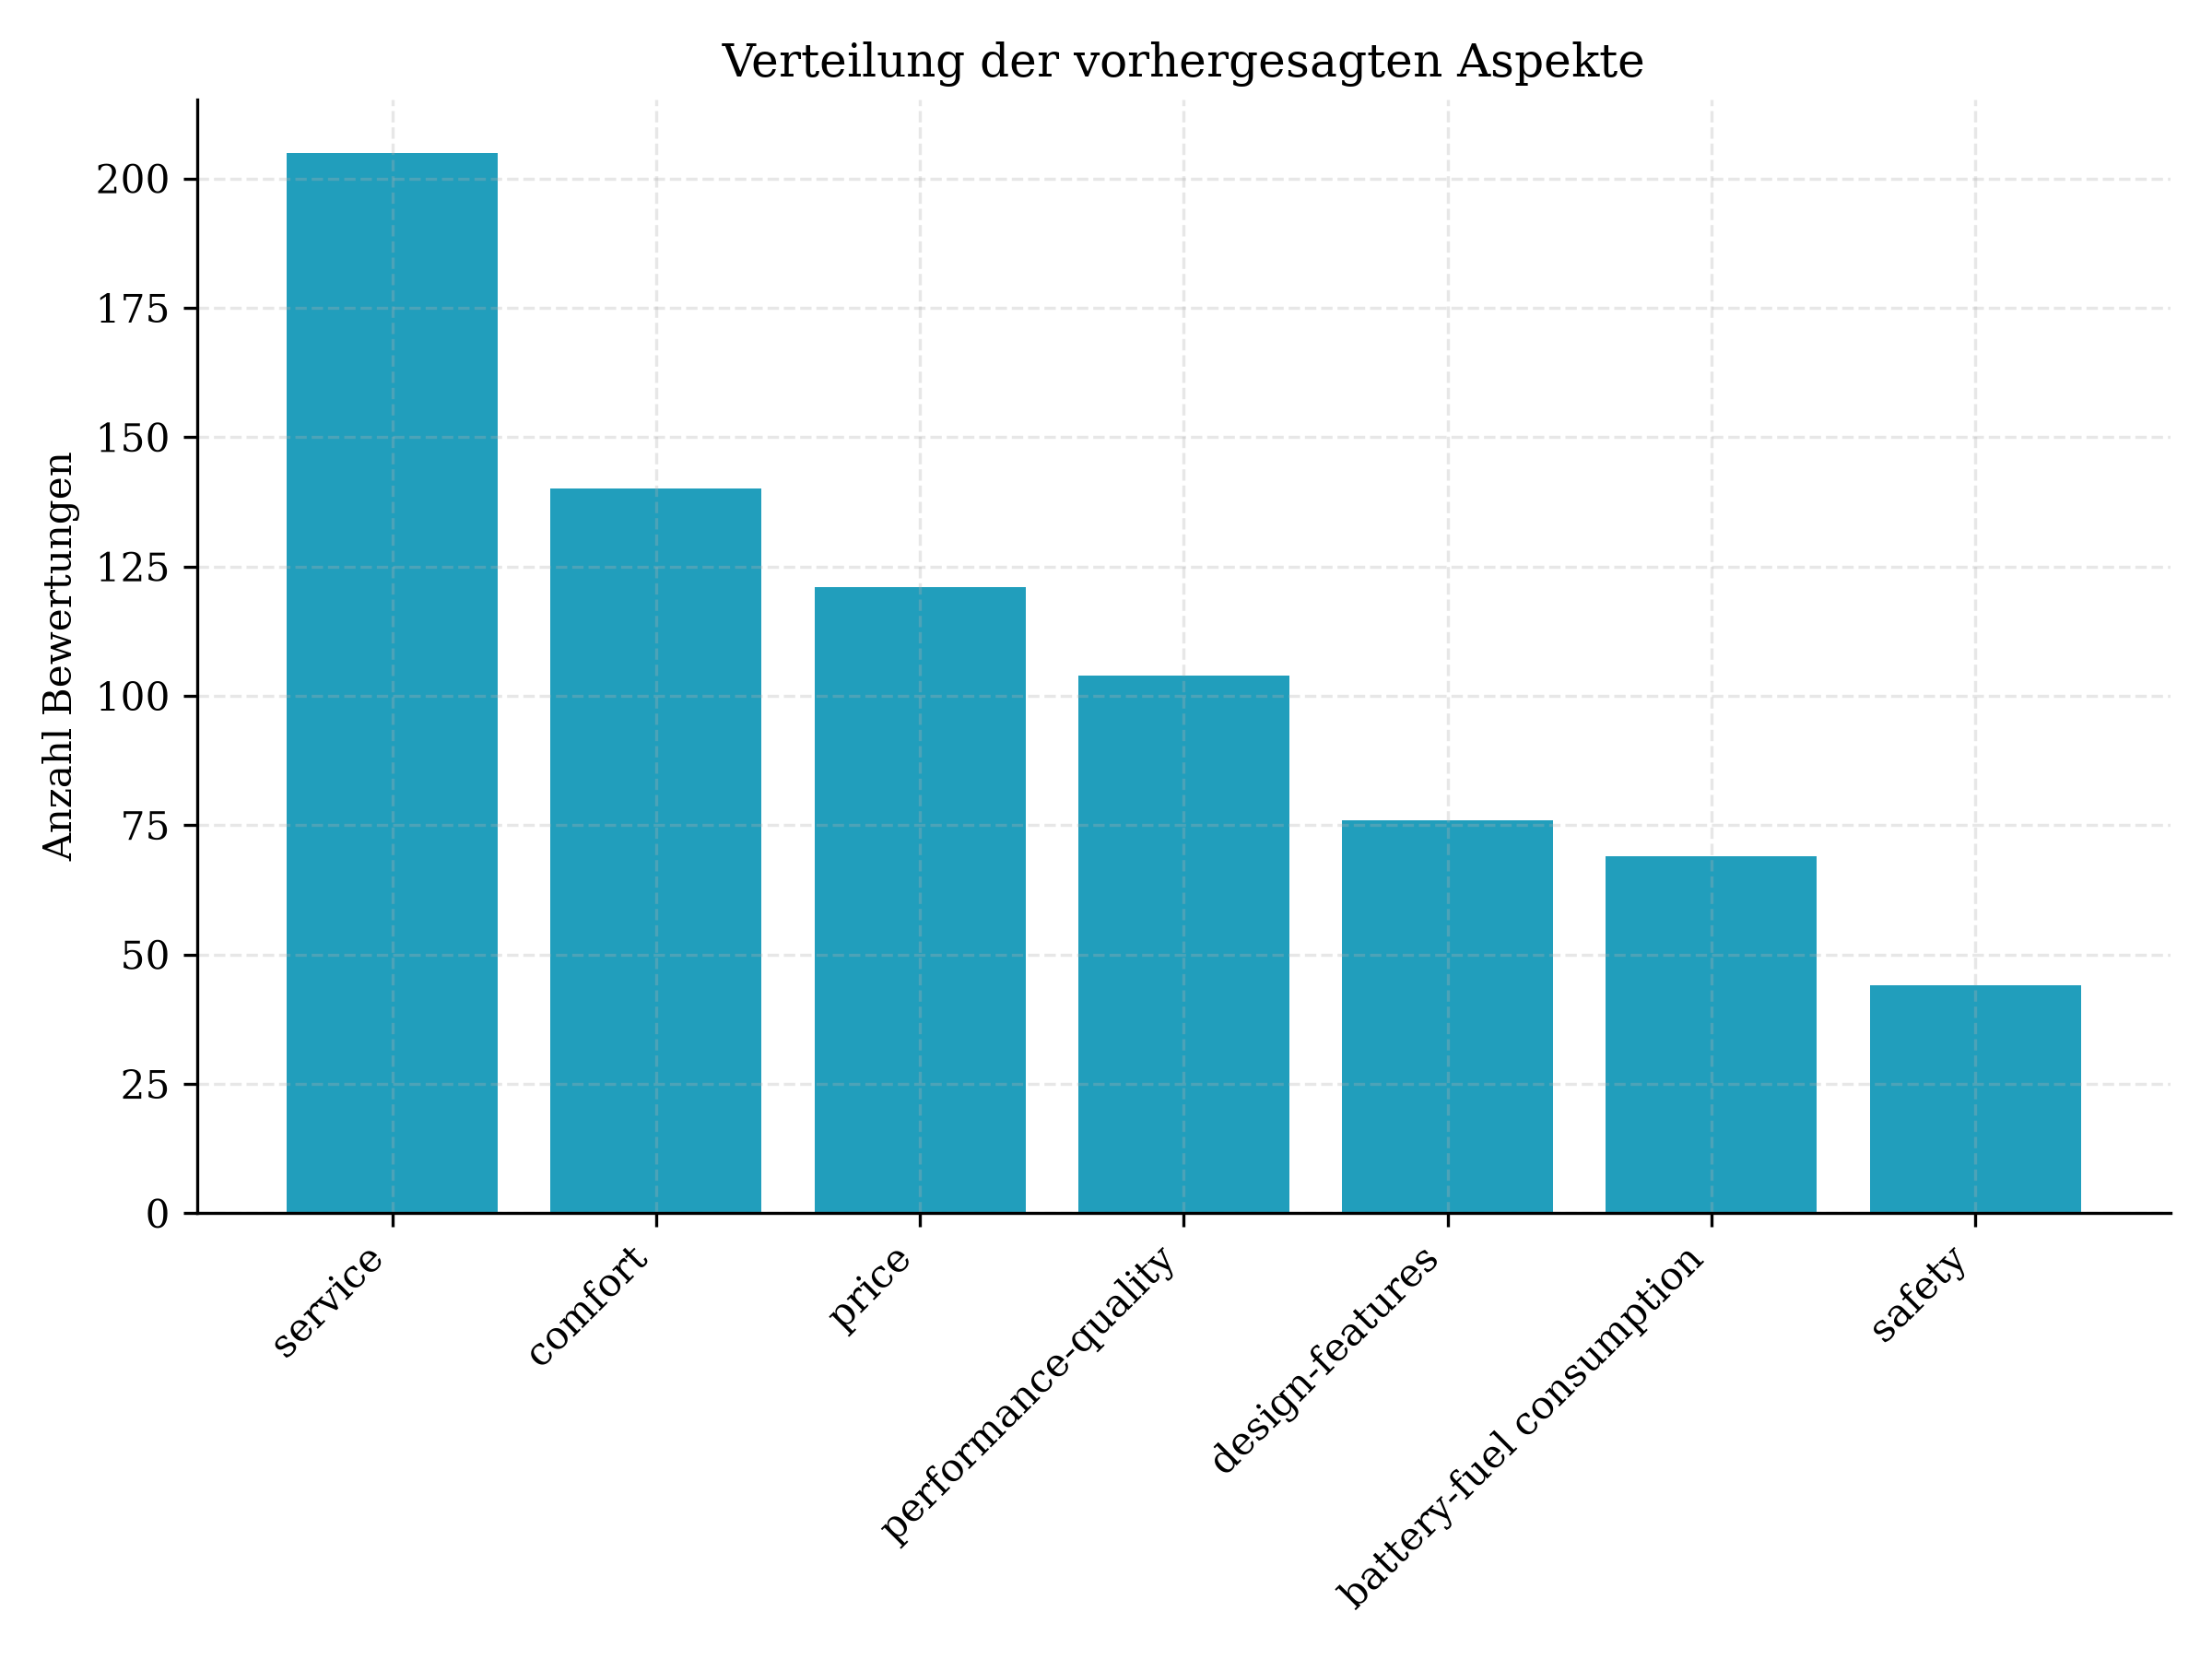

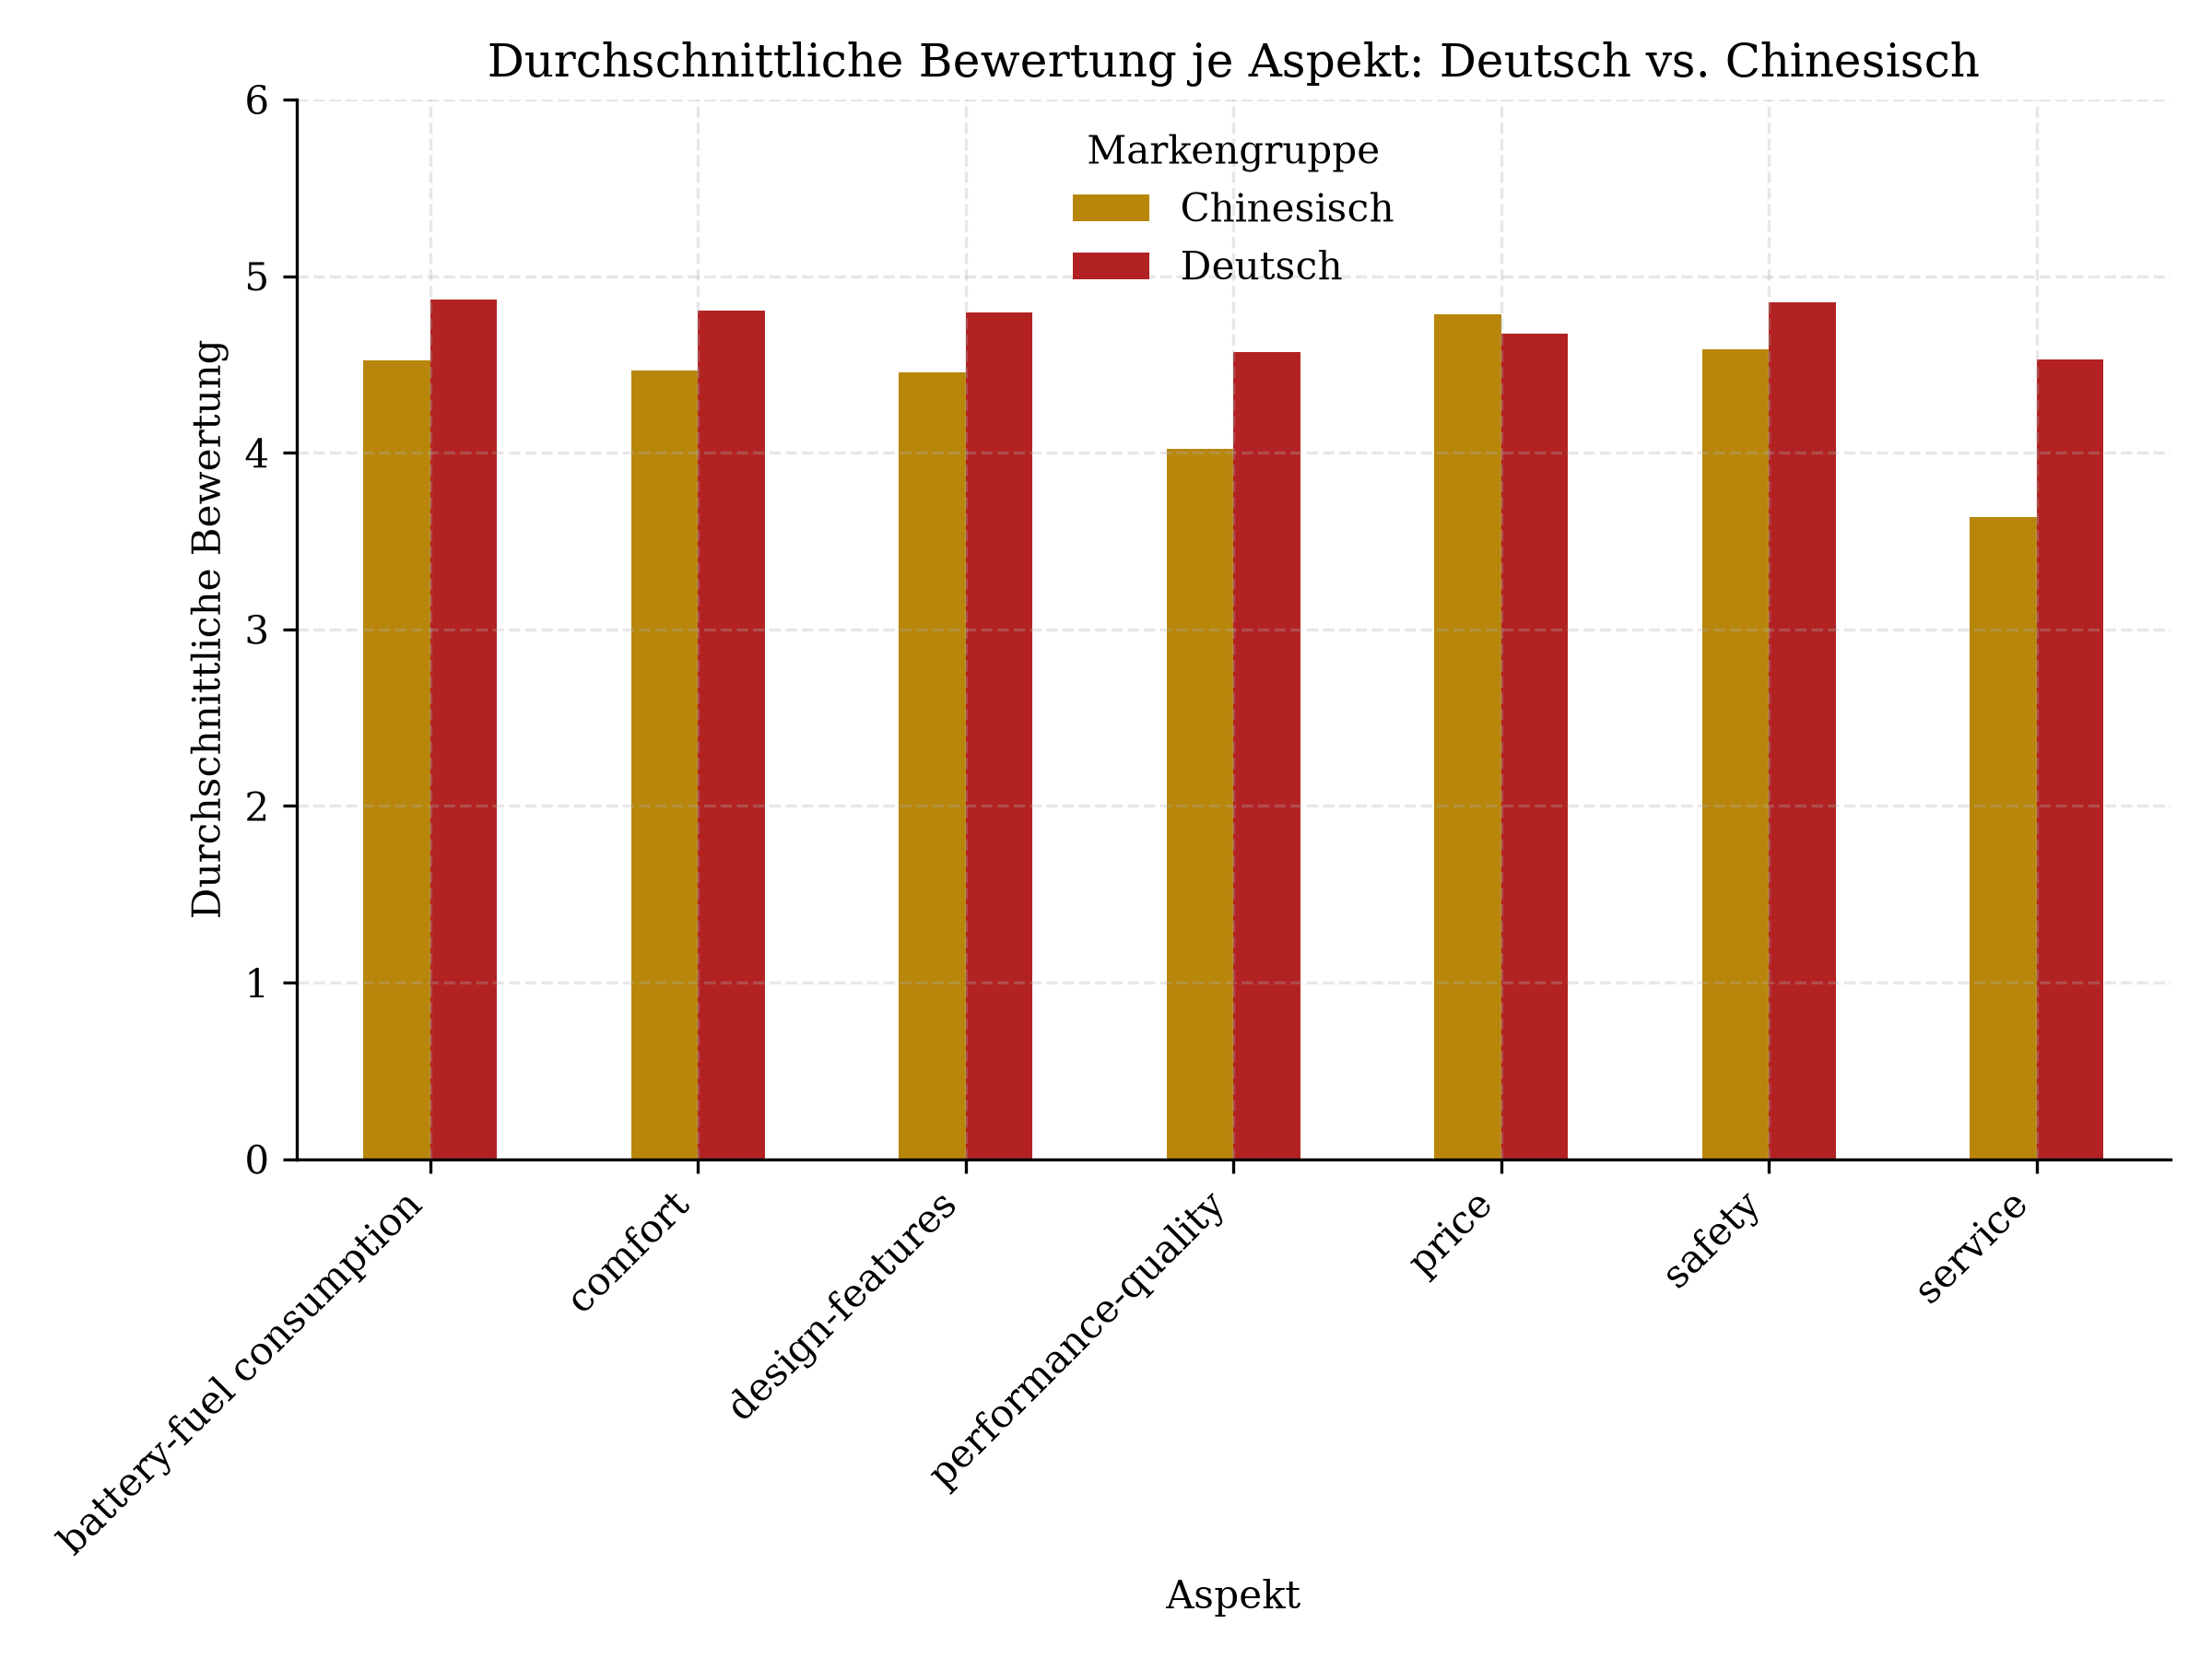

In [8]:
aspect_counts = predicted_reviews["predicted_aspect"].value_counts().to_dict()

pie_path = plot_predicted_aspect_distribution(
    aspect_counts, FIGURES_DIR / "reviews" / "predicted_aspect_pie.png", kind="pie"
)
bar_path = plot_predicted_aspect_distribution(
    aspect_counts, FIGURES_DIR / "reviews" / "predicted_aspect_bar.png", kind="bar"
)
rating_path = plot_average_rating_by_aspect_and_group(
    predicted_reviews, FIGURES_DIR / "reviews" / "average_rating_by_aspect_group.png"
)

display(Image(filename=str(pie_path)))
display(Image(filename=str(bar_path)))
display(Image(filename=str(rating_path)))

## Zusammenfassung

Dieses Kapitel misst, worüber echte Kundinnen und Kunden in ihren Fahrzeugbewertungen
sprechen -- ein eigens von Grund auf trainiertes NER-Modell extrahiert Aspekt-Entitäten
(Motor, Komfort, Service, Sicherheit, ...) aus realen CarWale-Bewertungen, ein darauf
aufbauender Klassifikator ordnet jeder Bewertung eine übergeordnete Aspektklasse zu. Die
KBA-/Schweiz-/Google-Trends-Kapitel (`consumer_interest_analysis.ipynb`) und das GDELT-Kapitel
(`news_media_nlp_analysis.ipynb`) bleiben die Quellen für reale Marktergebnisse bzw.
Medienberichterstattung -- dieses Kapitel ergänzt beide um die Perspektive realer
Kundenstimmen. Web-Scraping und NER-Training sind live/cache-fähig und zwischenspeichern
jeden Fortschritt einzeln (siehe Einführung oben), sodass ein erneuter Lauf nichts bereits
Erledigtes wiederholt. Abbildungen werden unter `artifacts/figures/reviews/` gespeichert;
`scripts/scrape_reviews.py` und `scripts/train_review_models.py` bieten denselben Ablauf als
reproduzierbare Kommandozeilen-Einstiegspunkte.
